<b>Imports</b>

In [160]:
import collections
import json
import math
import os
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from PIL import Image
from tqdm import tqdm

<b>Chargement des données</b>

In [161]:
# Chemin du fichier d'annotations
DATA_PATH = os.path.abspath(
    './COCO')
ANNOTATION_FILE = os.path.join(DATA_PATH, "annotations", "captions_train2014.json")
IMAGE_FOLDER = os.path.join(DATA_PATH, "train2014")
PATH = IMAGE_FOLDER + os.sep
MODEL_SAVED_PATH = 'saved_models'
ENCODER_PATH = os.path.join(MODEL_SAVED_PATH, 'encoder.keras')
DECODER_PATH = os.path.join(MODEL_SAVED_PATH, 'decoder.keras')

# Paramètres
EPOCHS = 5
TOP_WORD_FREQUENCY = 5000
BATCH_SIZE = 64  # taille du batch
BUFFER_SIZE = 1000  # taille du buffer pour melanger les donnes
embedding_dim = 256
units = 512  # Taille de la couche cachée dans le RNN
vocab_size = TOP_WORD_FREQUENCY + 1
LIMIT_DATA = True # <-- Limite le nombre d'images à 200 pour le test

# La forme du vecteur extrait à partir d'InceptionV3 est (64, 2048)
# Les deux variables suivantes représentent la forme de ce vecteur.
features_shape = 2048
attention_features_shape = 64

In [162]:
def load_annotations():
    print("Loading annotations...")
    # Lecture du fichier d'annotation
    with open(ANNOTATION_FILE, 'r') as f:
        annotations = json.load(f)

    # Grouper toutes les annotations ayant le meme identifiant.
    image_path_to_caption = collections.defaultdict(list)
    for val in annotations['annotations']:
        # marquer le debut et la fin de chaque annotation
        caption = '<start> ' + val['caption'] + ' <end>'
        # L'identifiant d'une image fait partie de son chemin d'accès
        image_path = PATH + 'COCO_train2014_' + '%012d.jpg' % (val['image_id'])
        # Rajout du caption associé à image_path
        image_path_to_caption[image_path].append(caption)

    # Prendre les premières images seulement
    image_paths = list(image_path_to_caption.keys())

    if LIMIT_DATA:
        train_image_paths = image_paths[:200]

    # Liste de toutes les annotations
    train_captions = []
    # Liste de tous les noms de fichiers des images dupliquées (en nombre d'annotations par image)
    img_name_vector = []

    for image_path in train_image_paths:
        caption_list = image_path_to_caption[image_path]
        # Rajout de caption_list dans train_captions
        train_captions.extend(caption_list)
        # Rajout de image_path dupliquée len(caption_list) fois
        img_name_vector.extend([image_path] * len(caption_list))

    return train_captions, img_name_vector

In [163]:
train_captions, img_name_vector = load_annotations()

Loading annotations...


In [164]:
def load_inceptionV3():
    print("Loading InceptionV3 model...")
    # Telechargement du modèle InceptionV3 pré-entrainé avec la classification sur ImageNet
    image_model = tf.keras.applications.InceptionV3(include_top=False,
                                                    weights='imagenet')
    # Creation d'une variable qui sera l'entrée du nouveau modèle de pre-traitement d'images
    new_input = image_model.input
    # Récupérer la dernière couche cachée qui contient l'image en représentation compacte
    hidden_layer = image_model.layers[-1].output

    # Modèle qui calcule une représentation dense des images avec InceptionV3
    return tf.keras.Model(inputs=new_input, outputs=hidden_layer)

In [165]:
image_features_extract_model = load_inceptionV3()

Loading InceptionV3 model...


In [166]:
# Définition de la fonction load_image
def load_image(image_path):
    """
    La fonction load_image a pour entrée le chemin d'une image et pour sortie un couple
    contenant l'image traitée ainsi que son chemin d'accès.
    La fonction load_image effectue les traitements suivants:
        1. Chargement du fichier correspondant au chemin d'accès image_path
        2. Décodage de l'image en RGB.
        3. Redimensionnement de l'image en taille (299, 299).
        4. Normalisation des pixels de l'image entre -1 et 1
    """
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (299, 299))
    img = tf.keras.applications.inception_v3.preprocess_input(img)
    return img, image_path

In [167]:
def preprocess_images():
    # Prendre les noms des images
    encode_train = sorted(set(img_name_vector))

    # Creation d'une instance de "tf.data.Dataset" partant des noms des images
    image_dataset = tf.data.Dataset.from_tensor_slices(encode_train)
    # Division des données en batchs après application du pré-traitement fait par load_image
    image_dataset = image_dataset.map(
        load_image, num_parallel_calls=tf.data.experimental.AUTOTUNE).batch(16)

    skipped_images = 0
    processed_images = 0
    # Parcourir le dataset batch par batch pour effectuer le pré-traitement d'InceptionV3
    for img, path in tqdm(image_dataset):
        # Conversion des chemins en chaînes de caractères
        paths = [p.numpy().decode('utf-8') for p in path]

        # Création d'une liste d'indices d'images à traiter
        indices_to_process = []
        filtered_paths = []

        # Vérifiez quelles images ont déjà des features extraites
        for i, p in enumerate(paths):
            feature_path = p + '.npy'
            if not os.path.exists(feature_path):
                indices_to_process.append(i)
                filtered_paths.append(p)
            else:
                skipped_images += 1

        # S'il n'y a aucune image à traiter dans ce batch, passez au suivant
        if not indices_to_process:
            continue

        # Créez un sous-ensemble du batch pour les images à traiter
        sub_batch = tf.gather(img, indices_to_process)

        # Calculez les features uniquement pour les images non traitées
        batch_features = image_features_extract_model(sub_batch)
        batch_features = tf.reshape(
            batch_features,
            (batch_features.shape[0], -1, batch_features.shape[3])
        )

        # Sauvegardez les features
        for bf, p in zip(batch_features, filtered_paths):
            np.save(p, bf.numpy())
            processed_images += 1

        print(
            f"Traitement terminé: {processed_images} images traitées, {skipped_images} images ignorées car déjà traitées")

In [168]:
preprocess_images()

Loading image...


100%|██████████| 13/13 [00:00<00:00, 90.39it/s]


**Pré-traitement des annotations**

In [169]:
# Trouver la taille maximale 
def calc_max_length(tensor):
    return max(len(t) for t in tensor)


def preprocess_captions():
    # Chosir les 5000 mots les plus frequents du vocabulaire
    # La classe Tokenizer permet de faire du pre-traitement de texte pour reseau de neurones
    tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=TOP_WORD_FREQUENCY,
                                                      oov_token="<unk>",
                                                      filters='!"#$%&()*+.,-/:;=?@[\]^_`{|}~ ')
    # Construit un vocabulaire en se basant sur la liste train_captions
    tokenizer.fit_on_texts(train_captions)

    # Créer le token qui sert à remplir les annotations pour égaliser leur longueur
    tokenizer.word_index['<pad>'] = 0
    tokenizer.index_word[0] = '<pad>'

    # Creation des vecteurs (liste de token entier) à partir des annotations (liste de mots)
    train_seqs = tokenizer.texts_to_sequences(train_captions)

    # Remplir chaque vecteur jusqu'à la longueur maximale des annotations
    vector = tf.keras.preprocessing.sequence.pad_sequences(train_seqs, padding='post')

    # Calcule la longueur maximale qui est utilisée pour stocker les poids d'attention.
    # Elle servira plus tard pour l'affichage lors de l'évaluation
    maximum_length = calc_max_length(train_seqs)
    return tokenizer, vector, maximum_length

In [170]:
tokenizer, cap_vector, max_length = preprocess_captions()

# 1 Formation du jeu d'entrainement et de test :
Vous devez ensuite séparer le dataset en deux partie : un jeu d'entrainement et un jeu de test. Le code qui effectue ces opérations est détaillé dans la cellule suivante.

In [171]:
def create_train_val_dataset():
    img_to_cap_vector = collections.defaultdict(list)
    # Creation d'un dictionnaire associant les chemins des images avec (fichier .npy) aux annotations
    # Les images sont dupliquées, car il y a plusieurs annotations par image
    for img, cap in zip(img_name_vector, cap_vector):
        img_to_cap_vector[img].append(cap)

    """
    Création des datasets de formation et de validation en utilisant
    un fractionnement 80-20 de manière aléatoire
    """
    # Prendre les clés (noms des fichiers d'images traites), *celles-ci ne seront pas dupliquées*
    img_keys = list(img_to_cap_vector.keys())
    # Mélanger les clés pour garantir un fractionnement aléatoire
    random.shuffle(img_keys)
    # Diviser des indices en entrainement et test
    slice_index = int(len(img_keys) * 0.8)
    img_name_train_keys, img_name_val_keys = img_keys[:slice_index], img_keys[slice_index:]

    """
    Les jeux d'entrainement et de tests sont sous forme
    de listes contenants les mappings :(image prétraitée ---> jeton d'annotation(mot) )
    """

    # Boucle pour construire le jeu d'entrainement
    img_name_train = []
    cap_train = []
    for imgt in img_name_train_keys:
        capt_len = len(img_to_cap_vector[imgt])
        # Duplication des images en le nombre d'annotations par image
        img_name_train.extend([imgt] * capt_len)
        cap_train.extend(img_to_cap_vector[imgt])

    # Boucle pour construire le jeu de test
    img_name_val = []
    cap_val = []
    for imgv in img_name_val_keys:
        capv_len = len(img_to_cap_vector[imgv])
        # Duplication des images en le nombre d'annotations par image
        img_name_val.extend([imgv] * capv_len)
        cap_val.extend(img_to_cap_vector[imgv])

    print("Images d'entrainement:", len(img_name_train))
    print("Annotations d'entrainement:", len(cap_train))
    print("Images de test:", len(img_name_val))
    print("Annotations de test:", len(cap_val))

    return img_name_train, cap_train, img_name_val, cap_val

In [172]:
img_name_train, cap_train, img_name_val, cap_val = create_train_val_dataset()

Images d'entrainement: 801
Annotations d'entrainement: 801
Images de test: 200
Annotations de test: 200


Création d’un jeu de données d’entrainement représenté par une instance [`tf.data.Dataset`](https://www.tensorflow.org/api_docs/python/tf/data/Dataset) partant du jeu de données de base (les noms des fichiers et des annotations du jeu d’entrainement). La classe `tf.data.Dataset` sert à représenter des jeu de données volumineux et facilitent les prétraitements de ceux-ci.

In [173]:
# Fonction qui charge les fichiers numpy des images prétraitées
def map_func(img_name, cap):
    img_tensor = np.load(img_name.decode('utf-8') + '.npy')
    return img_tensor, cap


def create_train_dataset():
    # Creation d'un dataset de "Tensor"s (sert à représenter de grands dataset)
    # Le dataset est cree à partir de "img_name_train" et "cap_train"
    dataset = tf.data.Dataset.from_tensor_slices((img_name_train, cap_train))

    # L'utilisation de map permet de charger les fichiers numpy (possiblement en parallèle)
    dataset = dataset.map(lambda item1, item2: tf.numpy_function(
        map_func, [item1, item2], [tf.float32, tf.int32]),
                          num_parallel_calls=tf.data.experimental.AUTOTUNE)

    # Melanger les donnees et les diviser en batchs
    dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE)
    return dataset.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)

In [174]:
training_dataset = create_train_dataset()

**L'encodeur CNN :**



In [175]:
class CNN_Encoder(tf.keras.Model):
    # Comme les images sont déjà prétraitées par InceptionV3 et représentées sous forme compacte
    # L'encodeur CNN ne fera que transmettre ces caractéristiques à une couche dense
    def __init__(self, embedding_dim, **kwargs):
        kwargs.setdefault('name', 'cnn_encoder')
        super(CNN_Encoder, self).__init__(**kwargs)
        # forme après fc == (batch_size, 64, embedding_dim)
        self.embedding_dim = embedding_dim
        self.fc = tf.keras.layers.Dense(embedding_dim, activation='relu')

    def call(self, x):
        x = self.fc(x)
        x = tf.nn.relu(x)
        return x

    def get_config(self):
        config = super().get_config()
        config.update({
            "embedding_dim": self.embedding_dim,
        })
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

**Le mécanisme d'attention :**



Finalement, chaque caractéristique de la représentation de l’image en entrée sera multipliée (pondérée) par le vecteur d’attention. Après quoi, on prend la somme de chaque caractéristique le long des positions (les lignes de la représentation) pour former le **vecteur du contexte**.

De façon globale, on peut dire que le vecteur d’attention dépend de scores qui sont appris à partir d’une représentation spatiale et textuelle de l’image. Ce vecteur d’attention renvoie la pertinence de chaque position et sert à calculer le vecteur du contexte qui nous donnera l’importance des caractéristiques de l’image.

In [176]:
class BahdanauAttention(tf.keras.Model):
    def __init__(self, units):
        super(BahdanauAttention, self).__init__()
        self.W1 = tf.keras.layers.Dense(units)
        self.W2 = tf.keras.layers.Dense(units)
        self.V = tf.keras.layers.Dense(1)
        self.units = units

    def call(self, features, hidden):
        # features(CNN_encoder output) shape == (batch_size, 64, embedding_dim)

        # shape of hidden == (batch_size, hidden_size)
        # Adding time axis to hidden state to match the shape of features
        hidden_with_time_axis = tf.expand_dims(hidden, 1)

        # Passing through dense layers and adding them
        attention_hidden_layer = tf.nn.tanh(self.W1(features) + self.W2(hidden_with_time_axis))

        # Calculating the attention scores
        score = self.V(attention_hidden_layer)

        # Applying softmax to normalize the scores
        attention_weights = tf.nn.softmax(score, axis=1)

        # Calculating the context vector as the weighted sum of features
        context_vector = attention_weights * features
        context_vector = tf.reduce_sum(context_vector, axis=1)

        return context_vector, attention_weights

**Le décodeur RNN :**



In [177]:
class RNN_Decoder(tf.keras.Model):
    def __init__(self, embedding_dim, units, vocab_size, **kwargs):
        kwargs.setdefault('name', 'rnn_encoder')
        super(RNN_Decoder, self).__init__(**kwargs)
        self.units = units
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        # Embedding layer to convert word indices to dense vectors
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)

        # GRU layer
        self.gru = tf.keras.layers.GRU(self.units,
                                       return_sequences=True,
                                       return_state=True,
                                       recurrent_initializer='glorot_uniform')

        # Fully connected layer after GRU
        self.fc1 = tf.keras.layers.Dense(self.units)

        # Final fully connected layer to generate predictions
        self.fc2 = tf.keras.layers.Dense(vocab_size)

        # Attention mechanism
        self.attention = BahdanauAttention(self.units)

    def call(self, x, features, hidden):
        # Attention mechanism
        context_vector, attention_weights = self.attention(features, hidden)

        # Pass the input word through the embedding layer
        x = self.embedding(x)

        # Concatenate the context vector and the embedding
        x = tf.concat([tf.expand_dims(context_vector, 1), x], axis=-1)

        # Pass the concatenated vector through the GRU
        output, state = self.gru(x)

        # Pass the GRU output through the first fully connected layer
        y = self.fc1(output)

        # Reshape the output to prepare for the final fully connected layer
        y = tf.reshape(y, (-1, y.shape[2]))

        # Pass the reshaped output through the final fully connected layer
        y = self.fc2(y)

        return y, state, attention_weights

    def reset_state(self, batch_size):
        return tf.zeros((batch_size, self.units))

    def get_config(self):
        config = super(RNN_Decoder, self).get_config()
        config.update({
            "embedding_dim": self.embedding_dim,
            "units": self.units,
            "vocab_size": self.vocab_size,
        })
        return config

    @classmethod
    def from_config(cls, config):
        return cls(
            embedding_dim=config["embedding_dim"],
            units=config["units"],
            vocab_size=config["vocab_size"]
        )

**Combiner la partie encodeur et décodeur :**

Vous devez compléter la partie du code pour la création de l'encodeur et du décodeur.

In [178]:
# Création de l'encodeur
encoder = CNN_Encoder(embedding_dim)

# Création du décodeur
decoder = RNN_Decoder(embedding_dim, units, vocab_size)


In [179]:
# Optimiseur ADAM
optimizer = tf.keras.optimizers.Adam()

# La fonction de perte
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True, reduction='none')


def loss_function(real, pred):
    mask = tf.math.logical_not(tf.math.equal(real, 0))
    loss_ = loss_object(real, pred)

    mask = tf.cast(mask, dtype=loss_.dtype)
    loss_ *= mask

    return tf.reduce_mean(loss_)

Initialisation de l'époque de début d’entrainement dans `start_epoch`. La classe `tf.train.Checkpoint` permet de poursuivre l’entrainement là ou vous l’avez laissé s’il avait été interrompu auparavant.

# 3 Entrainement et test :


In [180]:
@tf.function
def train_step(img_tensor, target):
    loss = 0

    # Initialisation de l'état caché pour chaque batch
    hidden = decoder.reset_state(batch_size=target.shape[0])

    # Initialiser l'entrée du décodeur
    dec_input = tf.expand_dims([tokenizer.word_index['<start>']] * target.shape[0], 1)

    with tf.GradientTape() as tape:  # Offre la possibilité de calculer le gradient du loss
        features = encoder(img_tensor)

        for i in range(1, target.shape[1]):
            # Prédiction des i'èmes mot du batch avec le décodeur
            predictions, hidden, _ = decoder(dec_input, features, hidden)
            loss += loss_function(target[:, i], predictions)

            # Le mot correct à l'étap i est donné en entrée à l'étape (i+1)
            dec_input = tf.expand_dims(target[:, i], 1)

    total_loss = (loss / int(target.shape[1]))

    trainable_variables = encoder.trainable_variables + decoder.trainable_variables

    gradients = tape.gradient(loss, trainable_variables)

    optimizer.apply_gradients(zip(gradients, trainable_variables))

    return loss, total_loss


 Epoch 1/5


Training: 13it [00:27,  2.15s/it, Batch Loss=2.0817]                                                


Nouvelle meilleure loss détectée (2.357882) → sauvegarde du modèle...
 Epoch 1 finished - Avg Train Loss: 2.357882
 Time taken: 28.04 sec

 Epoch 2/5


Training: 13it [00:28,  2.17s/it, Batch Loss=2.1551]                                                


Nouvelle meilleure loss détectée (2.263566) → sauvegarde du modèle...
 Epoch 2 finished - Avg Train Loss: 2.263566
 Time taken: 28.28 sec

 Epoch 3/5


...

Training: 13it [00:25,  1.97s/it, Batch Loss=1.9554]                                                


Nouvelle meilleure loss détectée (2.090664) → sauvegarde du modèle...
 Epoch 4 finished - Avg Train Loss: 2.090664
 Time taken: 25.74 sec

 Epoch 5/5


Training: 13it [00:27,  2.13s/it, Batch Loss=1.8799]                                                

Nouvelle meilleure loss détectée (1.986293) → sauvegarde du modèle...
 Epoch 5 finished - Avg Train Loss: 1.986293
 Time taken: 27.83 sec


Text(0.5, 1.0, 'Loss Plot')

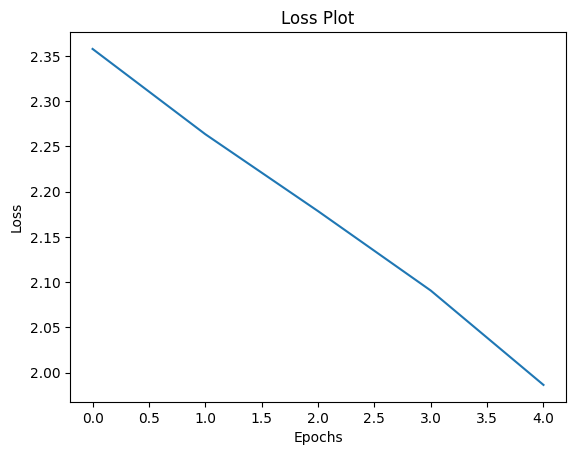

In [185]:
start_epoch = 0
loss_plot = []
num_steps = len(img_name_train) // BATCH_SIZE
best_loss = float('inf')

for epoch in range(start_epoch, EPOCHS):
    start = time.time()
    total_loss = 0

    print(f"\n Epoch {epoch + 1}/{EPOCHS}")
    pbar = tqdm(enumerate(training_dataset), total=num_steps, desc="Training", ncols=100)

    for batch, (img_tensor, target) in pbar:
        batch_loss, t_loss = train_step(img_tensor, target)
        total_loss += t_loss

        if batch % 10 == 0:
            pbar.set_postfix({
                "Batch Loss": f"{(batch_loss.numpy() / int(target.shape[1])):.4f}"
            })

    loss_plot.append(total_loss / num_steps)
    avg_loss = total_loss / num_steps
    if avg_loss < best_loss:
        best_loss = avg_loss
        print(f"Nouvelle meilleure loss détectée ({best_loss:.6f}) → sauvegarde du modèle...")

        encoder.save(ENCODER_PATH)
        decoder.save(DECODER_PATH)

    print(f" Epoch {epoch + 1} finished - Avg Train Loss: {avg_loss:.6f}")
    print(f" Time taken: {time.time() - start:.2f} sec")

# Affichage de la courbe d'entrainement
plt.plot(loss_plot)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Plot')

# Charger les modèles

In [182]:
best_encoder = tf.keras.models.load_model(ENCODER_PATH, custom_objects={'CNN_Encoder': CNN_Encoder})
best_decoder = tf.keras.models.load_model(DECODER_PATH, custom_objects={'RNN_Decoder': RNN_Decoder})

# 3.2 Test
La fonction qui permet d'achever une étape d'evaluation pour le test est dans la cellule suivante. 

In [183]:
def evaluate(image):
    attention_plot = np.zeros((max_length, attention_features_shape))

    hidden = decoder.reset_state(batch_size=1)

    temp_input = tf.expand_dims(load_image(image)[0], 0)
    img_tensor_val = image_features_extract_model(temp_input)
    img_tensor_val = tf.reshape(img_tensor_val, (img_tensor_val.shape[0], -1, img_tensor_val.shape[3]))

    features = encoder(img_tensor_val)

    dec_input = tf.expand_dims([tokenizer.word_index['<start>']], 0)
    result = []

    for i in range(max_length):
        predictions, hidden, attention_weights = decoder(dec_input, features, hidden)

        attention_plot[i] = tf.reshape(attention_weights, (-1,)).numpy()

        predicted_id = tf.random.categorical(predictions, 1)[0][0].numpy()
        predicted_word = tokenizer.index_word.get(predicted_id, '<unk>')  # Use .get() to handle missing keys
        result.append(predicted_word)

        if predicted_word == '<end>':
            return result, attention_plot

        dec_input = tf.expand_dims([predicted_id], 0)

    attention_plot = attention_plot[:len(result), :]
    return result, attention_plot


# Fonction permettant la représentation de l'attention au niveau de l'image
def plot_attention(image, result, attention_plot):
    temp_image = np.array(Image.open(image))

    fig = plt.figure(figsize=(10, 10))

    len_result = len(result)
    grid_size = math.ceil(math.sqrt(len_result))

    for l in range(len_result):
        temp_att = np.resize(attention_plot[l], (8, 8))
        ax = fig.add_subplot(grid_size, grid_size, l + 1)
        ax.set_title(result[l])
        img = ax.imshow(temp_image)
        ax.imshow(temp_att, cmap='gray', alpha=0.6, extent=img.get_extent())
        ax.axis('off')  # Optionnel : retirer les axes pour un visuel plus propre

    plt.tight_layout()
    plt.show()


L'affichage de quelques exemples sur le résultat retourné par l'évaluation. 

Loading image...
Real Caption: <start> a family watches while two boys play a singing game <end>
Prediction Caption: a cat stocked at standing baby <end>


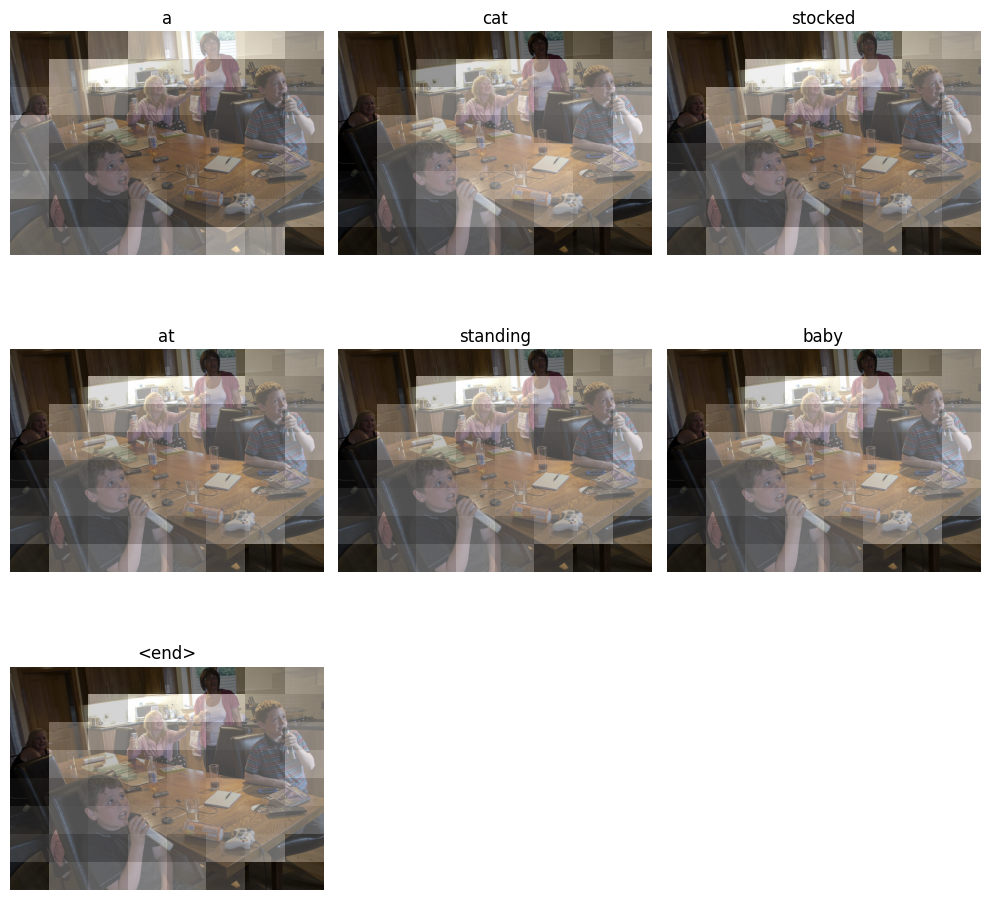

In [184]:
# Affichage de quelques annotations dans le jeu de test
rid = np.random.randint(0, len(img_name_val))
image = img_name_val[rid]
real_caption = ' '.join([tokenizer.index_word[i] for i in cap_val[rid] if i not in [0]])
result, attention_plot = evaluate(image)

print('Real Caption:', real_caption)
print('Prediction Caption:', ' '.join(result))
plot_attention(image, result, attention_plot)

### Evaluation du model

In [ ]:
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
from collections import defaultdict
from pycocoevalcap.cider.cider import Cider

nltk.download('wordnet')
nltk.download('omw-1.4')

def evaluate_metrics(img_name_val, cap_val, tokenizer, evaluate_fn, num_samples=100):
    bleu_scores = defaultdict(list)
    meteor_scores = []
    rouge_l_scores = []
    
    # Pour CIDEr, on prépare les formats COCO
    gts = {}  # ground truth
    res = {}  # result
    
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    cider_scorer = Cider()

    for i in range(num_samples):
        image = img_name_val[i]
        real_caption = [tokenizer.index_word[idx] for idx in cap_val[i] if idx not in [0]]
        reference = ' '.join(real_caption).replace('<start>', '').replace('<end>', '').strip()
        
        result, _ = evaluate_fn(image)
        predicted_caption = ' '.join(result).replace('<start>', '').replace('<end>', '').strip()

        reference_tokens = [reference.split()]
        predicted_tokens = predicted_caption.split()

        # BLEU scores
        smoothing = SmoothingFunction().method1
        bleu_scores[1].append(sentence_bleu(reference_tokens, predicted_tokens, weights=(1, 0, 0, 0), smoothing_function=smoothing))
        bleu_scores[2].append(sentence_bleu(reference_tokens, predicted_tokens, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothing))
        bleu_scores[3].append(sentence_bleu(reference_tokens, predicted_tokens, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smoothing))
        bleu_scores[4].append(sentence_bleu(reference_tokens, predicted_tokens, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothing))

        # METEOR
        # METEOR (corrigé avec tokenisation)
        meteor_scores.append(meteor_score(reference_tokens, predicted_tokens))

        # ROUGE-L
        rouge_score = scorer.score(reference, predicted_caption)['rougeL'].fmeasure
        rouge_l_scores.append(rouge_score)

        # Pour CIDEr
        gts[i] = [reference]
        res[i] = [predicted_caption]

    # Calcul final
    cider_score, _ = cider_scorer.compute_score(gts, res)

    print("\n📊 Évaluation du modèle sur", num_samples, "images:")
    print(f"BLEU-1: {sum(bleu_scores[1])/num_samples:.4f}")
    print(f"BLEU-2: {sum(bleu_scores[2])/num_samples:.4f}")
    print(f"BLEU-3: {sum(bleu_scores[3])/num_samples:.4f}")
    print(f"BLEU-4: {sum(bleu_scores[4])/num_samples:.4f}")
    print(f"METEOR: {sum(meteor_scores)/num_samples:.4f}")
    print(f"ROUGE-L: {sum(rouge_l_scores)/num_samples:.4f}")
    print(f"CIDEr: {cider_score:.4f}")

In [163]:
evaluate_metrics(img_name_val, cap_val, tokenizer, evaluate, num_samples=100)


📊 Évaluation du modèle sur 100 images:
BLEU-1: 0.1184
BLEU-2: 0.0373
BLEU-3: 0.0216
BLEU-4: 0.0165
METEOR: 0.1017
ROUGE-L: 0.1659
CIDEr: 0.0625


### Analyse des Scores d'Évaluation du Modèle

**BLEU (1 à 4)**  
- **BLEU-1 : 0.1184**  
- **BLEU-2 : 0.0373**  
- **BLEU-3 : 0.0216**  
- **BLEU-4 : 0.0165**  

**Interprétation :**  
BLEU-1 indique que le modèle prédit des mots fréquents isolés, mais les scores BLEU-2 à BLEU-4 montrent que le modèle a du mal à capturer des relations entre les mots. Cela signifie que les séquences complexes, comme des phrases entières, sont difficiles à générer pour le modèle.

---

**METEOR**  
- **Score METEOR : 0.1017**  

**Interprétation :**  
METEOR est plus tolérant que BLEU, prenant en compte les synonymes et la flexibilité dans l’ordre des mots. Ce score indique que le modèle génère parfois des légendes pertinentes, mais qui ne sont pas identiques aux références.

---

**ROUGE-L**  
- **Score ROUGE-L : 0.1659**  

**Interprétation :**  
ROUGE-L mesure la correspondance des sous-séquences. Un score de 16.59% montre que certaines séquences sont bien capturées, mais les légendes restent courtes ou imprécises.

---

**CIDEr**  
- **Score CIDEr : 0.0625**  

**Interprétation :**  
CIDEr mesure la qualité des mots rares. Un score faible indique que le modèle n’utilise pas suffisamment de termes informatifs et spécifiques à l’image.

---

**Résumé Global :**  
Le modèle réussit à prédire des mots simples, mais a des difficultés avec des séquences complexes. Il manque de détails spécifiques dans ses légendes et peine à générer des descriptions longues et riches.

---